# Tinder for RL 
## RLI 22.00 · Group Assignment · IE University BCSAI · 2026

### Part 01

---

## Introduction

The MountainCar problem presented in this RL assignment is interesting because:
It's simple enough to be solved, yet it's difficult enough to show the fundamental differences between learning algorithms. MountainCar involves an under-powered car in a valley attempting to reach a flag on the top of the right hand hill. The car is too weak to drive directly up, gravity pulls it down to the valley. 

The only possible way is to learn how to build up momentum through trial and error by oscillating to the left and right until there's enough potential energy to reach the goal, an unexpected solution.


Our study is organized around four scenarios that cross two axes: **action space type** (discrete vs. continuous) and **reward/cost formulation** (minimize steps vs. minimize fuel). Within each scenario we compare two algorithms suited to that action space. Across scenarios with the same action space, we hold the algorithms fixed and vary only the reward, isolating the effect of reward engineering on the learned policy.

For the **discrete scenarios**, we compare **Q-Learning** against **DQN**. Q-Learning discretizes the state space into bins and builds an explicit lookup table, giving us a fully interpretable policy, every state's preferred action can be read directly from the table and visualized as a phase portrait. DQN replaces that table with a neural network, operating on the raw continuous state without discretization loss. The comparison directly answers whether function approximation adds value on a problem this small, or whether the tabular method is already sufficient.

For the **continuous scenarios**, tabular methods are infeasible. We compare **TD3** and **SAC**, both actor-critic algorithms that learn a policy network alongside a value estimator. TD3 is deterministic: it outputs a single action per state and stabilizes training through twin critics and delayed updates. SAC is stochastic: it maximizes a entropy-augmented objective, explicitly rewarding the agent for maintaining an exploratory, spread-out policy. This entropy regularization is particularly relevant here: in scenarios where large actions are penalized, SAC's natural tendency toward low-magnitude, high-entropy behavior aligns directly with the cost structure of the problem.

The four scenarios together enable both algorithm benchmarking and a principled analysis of how reward shaping alters policy structure (which is, ultimately, what this assignment is about).






---



## Scenario 1 — Discrete MountainCar: Minimum Steps

**Environment**: `MountainCar-v0` · **Objective**: Reach the goal in as few timesteps as possible

---

The first scenario uses the discrete version of MountainCar with its default reward structure: the agent receives **−1 for every timestep** until it reaches the flag. The default environment provides no partial credit or progress signal (just a constant −1 penalty per timestep), so both algorithms add a +100 goal bonus during training to enable discovery, while evaluation uses the unmodified reward to measure true performance.

This makes the problem deceptively hard: 

the agent must stumble upon the goal through exploration before it can learn anything meaningful, and early in training almost every episode simply truncates at 200 steps.

The action space has three choices at each step: push left (0), do nothing (1), or push right (2). The optimal policy is not "always push right", the car would lack the torque to climb directly. It must learn to rock back and forth, building kinetic energy through momentum before committing to the final climb. This emergent behavior is what makes Scenario 1 a clean test of whether an algorithm can discover a multi-step, physically-grounded strategy from a sparse, undifferentiated reward signal.


### Algorithms

**Q-Learning** discretizes the continuous state space into a **40×40 grid** (position × velocity), yielding 1,600 discrete states. Each cell maps to a Q-value for each of the 3 actions, updated via the Bellman equation with a learning rate of **α = 0.1**, small enough for stable updates, large enough to learn within 25,000 episodes. The discount factor **γ = 0.99** keeps future rewards nearly as valuable as immediate ones, which matters here because the goal can only be reached many steps into the future. Exploration follows ε-greedy decay from **1.0 → 0.02** at a rate of **0.9997 per episode**, giving the agent a long exploratory phase before committing to a policy. Because the default −1/step signal is too sparse for tabular bootstrapping to work reliably, we add a **+100 goal bonus** on termination, this preserves the optimal policy ordering while giving the Q-table a concrete value to propagate backwards from. All randomness is seeded at **seed = 42**, applied to both `np.random` and the environment reset.

**DQN** uses the **same +100 goal bonus**, applied via a `ShapedMountainCar` gym wrapper that intercepts the reward on termination before it reaches the replay buffer. This is a deliberate design choice: by keeping the reward structure identical across both algorithms, any performance difference in Scenario 1 is attributable to the algorithm itself (tabular vs. function approximation)  rather than to asymmetric learning signals. The network is a **two-layer MLP [128, 128]** mapping the raw continuous state directly to Q-values. Learning rate is **5e-4**, with a **replay buffer of 50,000 transitions** and a **1,000-step warmup** before any gradient updates. Batches of **64 transitions** are sampled every **4 environment steps**, and the target network hard-updates every **1,000 steps**. Exploration decays from **1.0 → 0.02** over **35% of total timesteps**. Trained for **200,000 environment steps** at **seed = 42**.

Both algorithms are evaluated on the **unmodified −1/step reward**, the shaping is training-only. This separates the engineered learning signal from the true objective performance, making the evaluation metrics directly comparable across scenarios.

In [3]:
import json
import numpy as np
from pathlib import Path

SCENARIO1_DIR = Path("results/scenario1")

with open(SCENARIO1_DIR / "training/results/scenario1/metrics/scenario1_qtable.json") as f:
    qtable_metrics = json.load(f)

with open(SCENARIO1_DIR / "training/results/scenario1/metrics/scenario1_dqn.json") as f:
    dqn_metrics = json.load(f)

metrics_to_show = [
    ("Success Rate (%)",     "success_rate_percent"),
    ("Avg Reward",           "average_reward"),
    ("Avg Steps",            "average_steps"),
    ("Avg Fuel",             "average_fuel"),
    ("Min Steps",            "min_steps"),
    ("Max Steps",            "max_steps"),
    ("Training Time (s)",    "training_time_seconds"),
]

print(f"{'Metric':<25} {'Q-Learning':>15} {'DQN':>15}")
print("-" * 57)
for label, key in metrics_to_show:
    q_val = qtable_metrics.get(key, "N/A")
    d_val = dqn_metrics.get(key, "N/A")
    if isinstance(q_val, float):
        print(f"{label:<25} {q_val:>15.2f} {d_val:>15.2f}")
    else:
        print(f"{label:<25} {str(q_val):>15} {str(d_val):>15}")

FileNotFoundError: [Errno 2] No such file or directory: 'results/scenario1/training/results/scenario1/metrics/scenario1_qtable.json'

FileNotFoundError: [Errno 2] No such file or directory: 'results/scenario1/plots/scenario1_qtable_training.png'

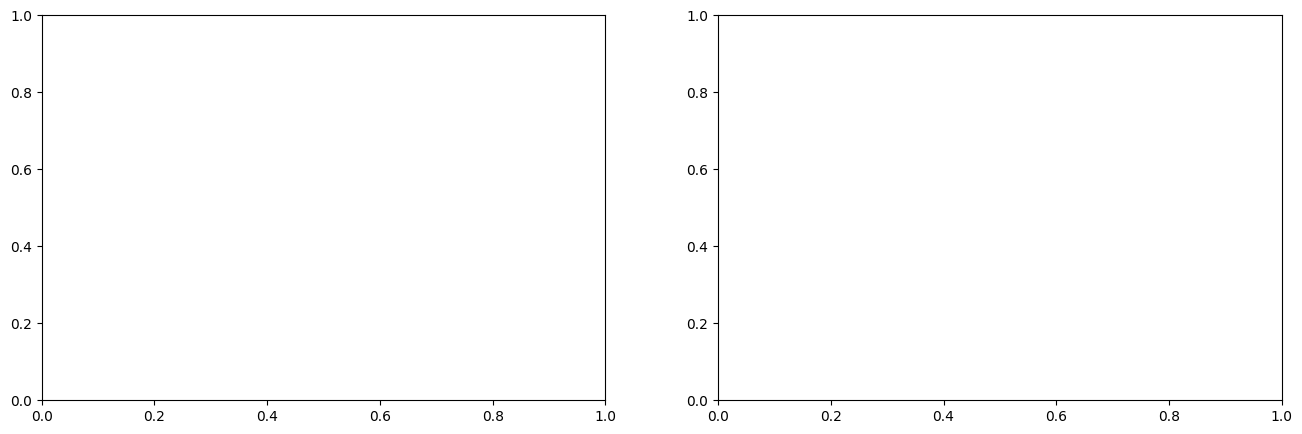

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

qtable_img = mpimg.imread(SCENARIO1_DIR / "plots/scenario1_qtable_training.png")
dqn_img    = mpimg.imread(SCENARIO1_DIR / "plots/scenario1_dqn_training.png")

axes[0].imshow(qtable_img)
axes[0].axis("off")
axes[0].set_title("Q-Learning — Training Curves", fontsize=13, fontweight="bold")

axes[1].imshow(dqn_img)
axes[1].axis("off")
axes[1].set_title("DQN — Training Curves", fontsize=13, fontweight="bold")

plt.suptitle("Scenario 1: Training Performance Comparison", fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
from mpl_toolkits.mplot3d import Axes3D

# Q-table value surface
qtable_values = np.max(q_table, axis=2).T

# DQN value surface via meshgrid inference
dqn_values = np.zeros((40, 40))
for i, v in enumerate(vel_range):
    for j, p in enumerate(pos_range):
        state = np.array([p, v], dtype=np.float32)
        obs_tensor = dqn_model.policy.obs_to_tensor(state)[0]
        with __import__("torch").no_grad():
            q_vals = dqn_model.policy.q_net(obs_tensor).cpu().numpy().flatten()
        dqn_values[i, j] = np.max(q_vals)

fig = plt.figure(figsize=(16, 6))

for idx, (values, title, color) in enumerate([
    (qtable_values, "Q-Learning Value Surface", "green"),
    (dqn_values,    "DQN Value Surface",        "red")
], 1):
    ax = fig.add_subplot(1, 2, idx, projection="3d")
    ax.plot_surface(POS, VEL, values, color=color, alpha=0.8, linewidth=0.3, edgecolor="k")
    ax.set_xlabel("Position")
    ax.set_ylabel("Velocity")
    ax.set_zlabel("V(s)")
    ax.set_title(title, fontweight="bold")

plt.suptitle("Scenario 1: Value Surfaces V(s) = max_a Q(s,a)", fontsize=14)
plt.tight_layout()
plt.show()

NameError: name 'q_table' is not defined

In [5]:
env = gym.make("MountainCar-v0")
N_EPISODES = 10

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (model_name, predict_fn) in zip(axes, [
    ("Q-Learning", lambda s: int(np.argmax(q_table[
        np.clip(np.digitize(s[0], position_bins) - 1, 0, 39),
        np.clip(np.digitize(s[1], velocity_bins) - 1, 0, 39)
    ]))),
    ("DQN", lambda s: int(dqn_model.predict(s.astype(np.float32), deterministic=True)[0]))
]):
    for ep in range(N_EPISODES):
        state, _ = env.reset()
        positions, velocities = [state[0]], [state[1]]
        total_reward = 0

        for _ in range(200):
            action = predict_fn(state)
            state, reward, terminated, truncated, _ = env.step(action)
            positions.append(state[0])
            velocities.append(state[1])
            total_reward += reward
            if terminated or truncated:
                break

        ax.plot(positions, velocities, alpha=0.6, linewidth=1.2, label=f"R={total_reward:.0f}")

    ax.axvline(x=0.5, color="gold", linestyle="--", linewidth=1.5, label="Goal")
    ax.set_xlabel("Position")
    ax.set_ylabel("Velocity")
    ax.set_title(f"{model_name} — Phase Portrait", fontweight="bold")
    ax.legend(fontsize=7, loc="upper left")

env.close()
plt.suptitle("Scenario 1: Trajectory Phase Portraits", fontsize=14)
plt.tight_layout()
plt.show()

NameError: name 'gym' is not defined